### Приложение

Зависимости

In [28]:
import pandas as pd
import numpy as np

считаем таблицу

In [29]:
df = pd.read_csv("Titanic-Dataset.csv")

выведем всю информацию о ней

In [30]:
print(df.head())
print(df.info())
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

Выведем отдельные столбцы и информацию об одной строке с помощью loc

In [79]:
# df["SibSp"].unique()
df["Parch"].unique()

array([0, 1, 2, 5, 3, 4, 6])

In [31]:
print(df["Age"])
print(df[["Age", "Fare"]])
print(df.loc[0])

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64
      Age     Fare
0    22.0   7.2500
1    38.0  71.2833
2    26.0   7.9250
3    35.0  53.1000
4    35.0   8.0500
..    ...      ...
886  27.0  13.0000
887  19.0  30.0000
888   NaN  23.4500
889  26.0  30.0000
890  32.0   7.7500

[891 rows x 2 columns]
PassengerId                          1
Survived                             0
Pclass                               3
Name           Braund, Mr. Owen Harris
Sex                               male
Age                               22.0
SibSp                                1
Parch                                0
Ticket                       A/5 21171
Fare                              7.25
Cabin                              NaN
Embarked                             S
Name: 0, dtype: object


мы можем спокойно применять агрегатные функции из numpy к pandas

In [32]:
mean_age = np.mean(df["Age"].dropna())
max_fare = np.max(df["Fare"])
mean_age, max_fare

(np.float64(29.69911764705882), np.float64(512.3292))

Также мы можем применять масочки как в numpy

In [33]:
adults = df[df["Age"] >= 18]
women = df[df["Sex"] == "female"]

Мы можем использовать group by как в sql, чтобы сгуппировать объекты по одному признаку

In [34]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()
print(survival_by_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


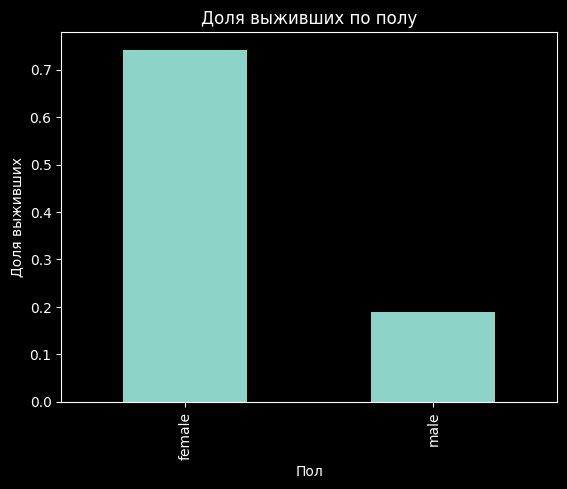

In [35]:
import matplotlib.pyplot as plt

survival_by_sex.plot(kind="bar")
plt.title("Доля выживших по полу")
plt.xlabel("Пол")
plt.ylabel("Доля выживших")
plt.show()

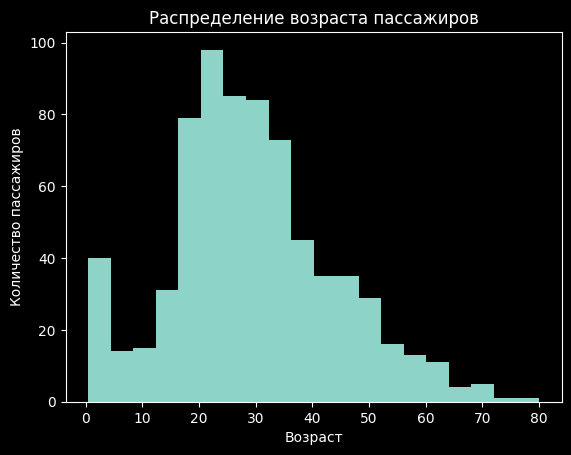

In [36]:
df["Age"].dropna().plot(kind="hist", bins=20)
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.show()

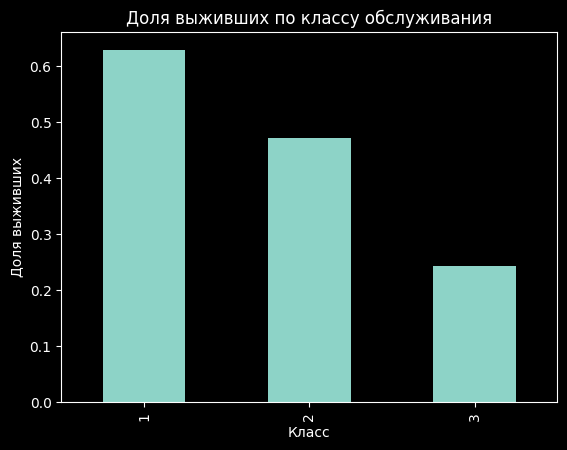

In [37]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class.plot(kind="bar")
plt.title("Доля выживших по классу обслуживания")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")
plt.show()

Линейный график

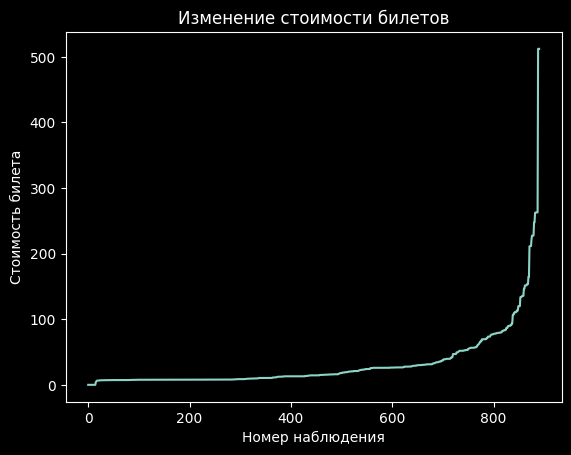

In [38]:
fare_sorted = df.sort_values("Fare")
plt.plot(fare_sorted["Fare"].values)
plt.title("Изменение стоимости билетов")
plt.xlabel("Номер наблюдения")
plt.ylabel("Стоимость билета")
plt.show()

Диаграмма рассеивания

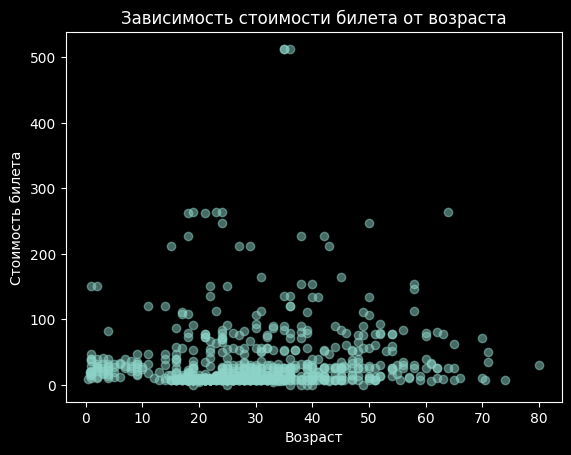

In [39]:
plt.scatter(df["Age"], df["Fare"], alpha=0.5)
plt.title("Зависимость стоимости билета от возраста")
plt.xlabel("Возраст")
plt.ylabel("Стоимость билета")
plt.show()

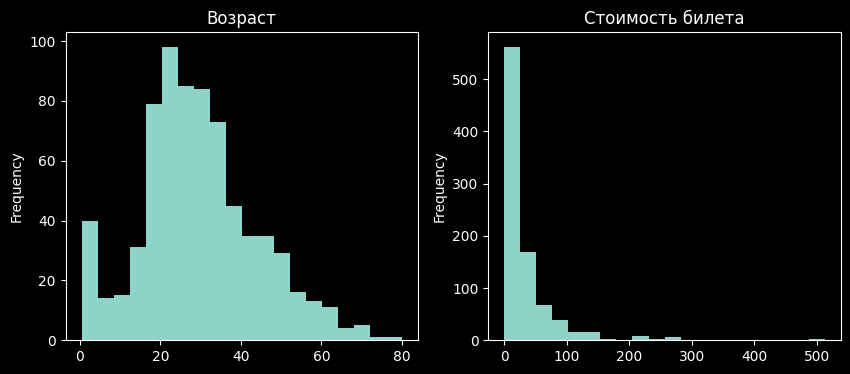

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df["Age"].dropna().plot(kind="hist", bins=20, ax=ax[0])
ax[0].set_title("Возраст")
df["Fare"].plot(kind="hist", bins=20, ax=ax[1])
ax[1].set_title("Стоимость билета")
plt.show()

### Начало лабораторной

In [55]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

так как датасет мы загрузили выше воспользуемся маской для поиска категориальных признаков

In [41]:
cat_features_mask = (df.dtypes == "str").values
cat_columns = df.columns[cat_features_mask]
cat_columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')

но на самом деле это немного странный датасет и тут некоторые признаки с числовым значением мы можем назвать категориальными и наоборот поэтому набор категориальных признаков будет вот такой:

In [74]:
cat_columns = pd.Index(["Name", "Sex", "Pclass", "Embarked", "Survived"])
cat_features_mask = df.columns.isin(cat_columns)
cat_columns

Index(['Name', 'Sex', 'Pclass', 'Embarked', 'Survived'], dtype='str')

таких признаков 5

In [75]:
num_columns = df.columns[~cat_features_mask]
num_columns

Index(['PassengerId', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare'], dtype='str')

2. Масочки

In [43]:
# масочка по полу
df_male = df[df["Sex"] == "male"]
df_female = df[df["Sex"] == "female"]
print(len(df_male), len(df_female))

577 314


In [44]:
# масочка по возрасту
above_18 = df[df["Age"] >= 18]
under_18 = df[df["Age"] < 18]
print(len(above_18), len(under_18))

601 113


In [45]:
# масочка по классу пассажира
first_class = df[df["Pclass"] == 1]
second_class = df[df["Pclass"] == 2]
third_class = df[df["Pclass"] == 3]
print(len(first_class), len(second_class), len(third_class))

216 184 491


Можно сказать, что они практически ничем не отличаются от numpy

3. Cредний возраст, пассажиров, максимальную и минимальную стоимость билета

In [46]:
avg_age_pd = df["Age"].mean()
avg_age_np = np.mean(df["Age"])
print(df["Age"].isna().sum())
print(avg_age_pd, avg_age_np)

max_ticket_price = df["Fare"].max()
min_ticket_price = df["Fare"].dropna().min()
print(max_ticket_price, min_ticket_price)
np_max_ticket_price = np.max(df["Fare"])
np_min_ticket_price = np.min(df["Fare"].dropna())
print(np_max_ticket_price, np_min_ticket_price)

177
29.69911764705882 29.69911764705882
512.3292 0.0
512.3292 0.0


функции работают абсолютно также как в numpy так как pandas основывается на numpy

4. Группировка

In [47]:
sex_class = df.groupby(['Sex', 'Pclass'])
survived_rate = sex_class["Survived"].mean()
avg_fare = sex_class["Fare"].mean()
avg_age = sex_class["Age"].mean()
print(survived_rate, avg_fare, avg_age)

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64 Sex     Pclass
female  1         106.125798
        2          21.970121
        3          16.118810
male    1          67.226127
        2          19.741782
        3          12.661633
Name: Fare, dtype: float64 Sex     Pclass
female  1         34.611765
        2         28.722973
        3         21.750000
male    1         41.281386
        2         30.740707
        3         26.507589
Name: Age, dtype: float64


так мы посчитали среднюю стоимость по сгруппированным значениям, чем-то они похожи на sql

5. Анализ null

для этого выведем все нулевые значения в строках

In [48]:
print(df.isnull().sum())
print("Всего пассажиров:", len(df))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Всего пассажиров: 891


Значит Cabin выкидываем, а в Age на медиану, Embarked заменим на больший класс (моду)

In [49]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(['Cabin'], axis=1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


6. Графики


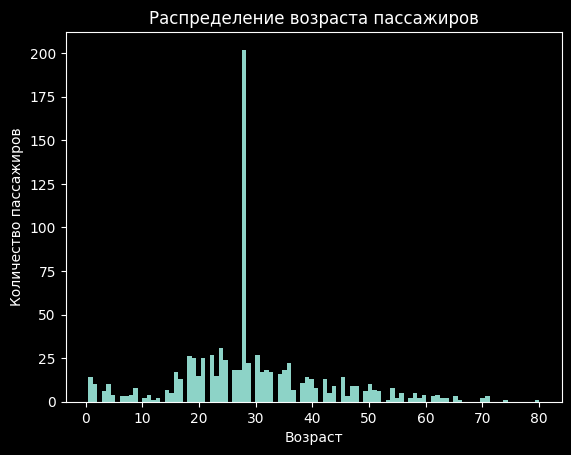

In [53]:
df["Age"].dropna().plot(kind="hist", bins=100)
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.show()

Выбросы пассажиры 0 лет и люди старше 70, основной диапазон значений 25-26 лет, так как туда попала медиана, которые мы назначили сторкам nan в графе возраст

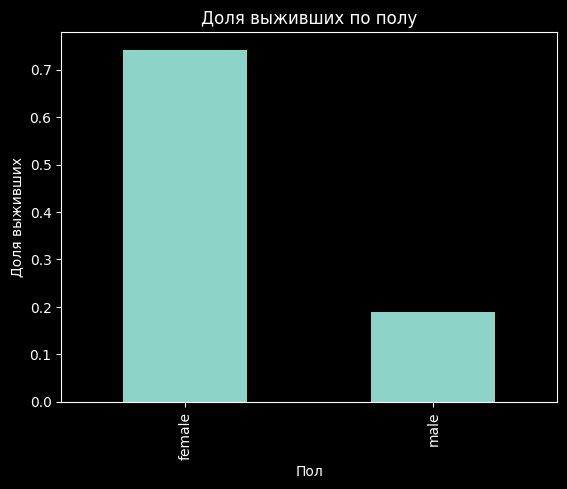

In [51]:
survival_by_sex.plot(kind="bar")
plt.title("Доля выживших по полу")
plt.xlabel("Пол")
plt.ylabel("Доля выживших")
plt.show()

Наблюдается резкая разница в выживаемости между женщинами и мужчинами. Доля выживших среди женщин составляет около 75%, в то время как среди мужчин — менее 20%.  Данная визуализация подтверждает исторический факт соблюдения правила «сначала женщины и дети». У женщин шансы на спасение были почти в 4 раза выше, чем у мужчин.

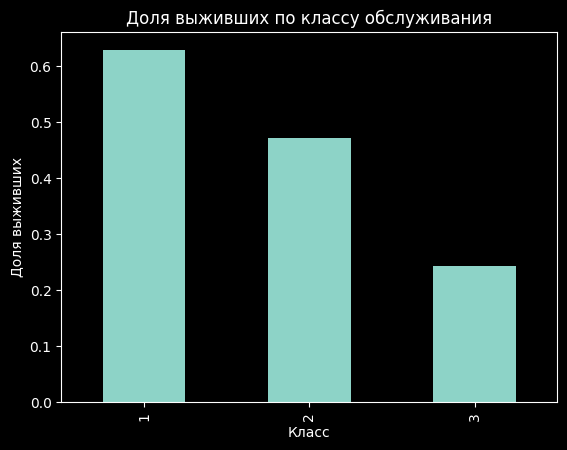

In [52]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class.plot(kind="bar")
plt.title("Доля выживших по классу обслуживания")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")
plt.show()

Наблюдается четкая зависимость между классом обслуживания и шансом выжить. Чем выше класс (меньше число), тем выше вероятность спасения.